# **"Implementation of the Isolation Forest Algorithm in Detecting Anomalous Parameters in Four-Wheeled Vehicle Data"**

##🧠 Goals:
####**Mendeteksi fitur (parameter sensor) yang menyimpang** pada data kendaraan yang memiliki kode kerusakan P0351, P0352, P0353, dan P0354 (Ignition Coil "A, B, C, dan D") menggunakan:
####**Algoritma Isolation Forest** → untuk deteksi anomali
####**SHAP (SHapley Additive exPlanations)** → untuk menjelaskan fitur mana yang berkontribusi pada anomali

### Vehicle Data: [Data Normal & Data Symptomatic](https://drive.google.com/drive/folders/1mM41Pv54S8DdGpfYMicOhzKU_avdYhTk?usp=sharing)

### Tidak menggunakan parameter numerik (konstan), parameter sinyal, parameter sinyal biner (changing), parameter spesifikasi

## *1. Import Data*

In [ ]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Markdown
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import Data Kendaraan Normal dan Rusak
data_normal = pd.read_csv('/content/drive/MyDrive/Trouble Scenario Data (Label)/Real Data/Label/Normal Data (Toyota) Label.csv')
data_symptomatic = pd.read_csv('/content/drive/MyDrive/Trouble Scenario Data (Label)/Real Data/Label/Failure Data (Toyota) Label.csv')

In [ ]:
# Ringkasan Tabel
display(Markdown("### Jumlah Data"))

summary = pd.DataFrame({
    "Dataset": ["Data Normal", "Data Symptomatic"],
    "Jumlah Baris": [data_normal.shape[0], data_symptomatic.shape[0]],
    "Jumlah Kolom": [data_normal.shape[1], data_symptomatic.shape[1]]
})

# Tambahkan total
total_baris = data_normal.shape[0] + data_symptomatic.shape[0]
total_kolom = data_normal.shape[1]
summary.loc[len(summary.index)] = ["Total", total_baris, total_kolom]

display(summary)


### Jumlah Data

,Dataset,Jumlah Baris,Jumlah Kolom
0,Data Normal,198,92
1,Data Symptomatic,198,92
2,Total,396,92


In [ ]:
# Tampilkan 5 data pertama
display(Markdown("### Data Normal (5 Baris Pertama)"))
display(data_normal.head())

display(Markdown("### Data Kondisi Rusak (5 Baris Pertama)"))
display(data_symptomatic.head())

### Data Normal (5 Baris Pertama)

,SampleTime,VehicleSpeed,EngineSpeed,CalculateLoad,MAF,AtmospherePressure,CoolantTemp,IntakeAir,EngineRunTime,InitialEngineCoolantTemp,...,IdleFuelCut,FCTAU,ModelCode,EngineType,CylinderNumber,TransmissionType,Destination,ModelYear,SystemIdentification,Label
0,00:00.000,0,753,19.6,2.93,97,75,28,271,45.6,...,0,0,0,0,4,1,0,2011,1,Normal
1,00:00.282,0,756,19.6,2.96,97,75,28,272,45.6,...,0,0,0,0,4,1,0,2011,1,Normal
2,00:00.565,0,759,19.2,2.92,97,75,28,272,45.6,...,0,0,0,0,4,1,0,2011,1,Normal
3,00:00.847,0,749,20.0,2.96,97,75,28,272,45.6,...,0,0,0,0,4,1,0,2011,1,Normal
4,00:01.130,0,756,19.6,2.95,97,75,28,272,45.6,...,0,0,0,0,4,1,0,2011,1,Normal


### Data Kondisi Rusak (5 Baris Pertama)

,SampleTime,VehicleSpeed,EngineSpeed,CalculateLoad,MAF,AtmospherePressure,CoolantTemp,IntakeAir,EngineRunTime,InitialEngineCoolantTemp,...,IdleFuelCut,FCTAU,ModelCode,EngineType,CylinderNumber,TransmissionType,Destination,ModelYear,SystemIdentification,Label
0,00:00.000,0,705,18.0,2.53,101,85,30,889,27.5,...,0,0,0,0,4,1,0,2011,1,Anomali
1,00:00.324,0,706,18.0,2.51,101,85,30,889,27.5,...,0,0,0,0,4,1,0,2011,1,Anomali
2,00:00.606,0,710,17.6,2.51,101,85,30,889,27.5,...,0,0,0,0,4,1,0,2011,1,Anomali
3,00:00.889,0,707,17.6,2.50,101,85,30,889,27.5,...,0,0,0,0,4,1,0,2011,1,Anomali
4,00:01.171,0,703,18.0,2.53,101,85,30,890,27.5,...,0,0,0,0,4,1,0,2011,1,Anomali


## *2. Preprocessing Data*


#### Data Intergration (Penggabunggan Data)

In [ ]:
# Gabungkan kedua data (Data Normal + Data Symptomatic (Data Kendaraan Rusak))
data_all = pd.concat([data_normal, data_symptomatic], ignore_index=True)

In [ ]:
print (data_all.dtypes)

SampleTime               object
VehicleSpeed              int64
EngineSpeed               int64
CalculateLoad           float64
MAF                     float64
                         ...   
TransmissionType          int64
Destination               int64
ModelYear                 int64
SystemIdentification      int64
Label                    object
Length: 92, dtype: object


#### Checking Missing Value

In [ ]:
# Cek missing value
missing_count = data_all.isnull().sum().sum()

# We will modify the logic to ensure 'Normal' data is not dropped
if missing_count == 0:
    print("Tidak ada missing value dalam dataset.")
    df = data_all.copy()
else:
    print(f"Ditemukan {missing_count} missing value. Mengisi nilai yang kosong.")
    # Apply ffill and fillna with mean directly on data_all to retain all rows
    df = data_all.copy() # Start with a copy to avoid modifying data_all directly if not intended
    df = df.ffill()
    df = df.fillna(df.mean(numeric_only=True))

# --- Now, df should contain both Normal and Anomali data with missing values handled ---

Tidak ada missing value dalam dataset.


#### Checking Duplicate Data

In [ ]:
def cek_duplikat(dataframe, nama_dataset):
    # Tentukan kolom yang diperiksa (kecuali SampleTime dan label)
    cols_to_check = [col for col in dataframe.columns if col not in ['SampleTime', 'label']]

    # Deteksi duplikat
    duplicate_rows = dataframe.duplicated(subset=cols_to_check, keep=False)
    duplicate_count = duplicate_rows.sum()

    # Tampilkan hasil
    if duplicate_count == 0:
        print(f"Tidak ada duplikat dalam {nama_dataset}.")
    else:
        print(f"Terdapat {duplicate_count} baris duplikat dalam {nama_dataset}. Menampilkan contoh:")
        display(dataframe[duplicate_rows].head())

        # (Opsional) Hapus duplikat jika ingin
        print(f"Menghapus duplikat dari {nama_dataset}...")
        dataframe = dataframe.drop_duplicates(subset=cols_to_check)
        print(f"Duplikat dalam {nama_dataset} berhasil dihapus.")

    return dataframe

# 🔍 Cek masing-masing dataset secara terpisah
data_normal = cek_duplikat(data_normal, "Data Normal")
data_symptomatic = cek_duplikat(data_symptomatic, "Data Symptomatic")

# 🔗 Gabungkan kembali setelah duplikat dihapus (jika diinginkan)
data_all = pd.concat([data_normal, data_symptomatic], ignore_index=True)
df = data_all.copy()


Tidak ada duplikat dalam Data Normal.
Tidak ada duplikat dalam Data Symptomatic.


#### Drop Feature (Feature Selection)

In [ ]:
fitur_dibuang = [
    # --- Parameter Numerik ---
    # "CalculateLoad", "MAF", "CoolantTemp", "Injector(Port)", "BatteryVoltage",
    # "AccelSens.No.1Volt%", "AccelSens.No.2Volt%", "AccelSensorOutNo.1",
    # "AccelSensorOutNo.2", "AccelFullyClose#1(AD)", "AccelFullyCloseLearn#1",
    # "AccelFullyCloseLearn#2", "ThrottleSensorVolt%", "ThrottleSensor2Volt%",
    # "ThrottleRequirePosition", "ThrottleSensorPosition", "ThrottlePositionNo.1",
    # "ThrottlePositionNo.2", "ThrottlePositionCommand", "ThrottleSensOpen#1(AD)",
    # "ThrottleMotorCurrent", "ThrottleMotorDUTY", "ThrottleMotorDuty(Open)",
    # "ThrottleMotorDuty(Close)", "+BMVoltage", "InjectionVolum(Cylinder1)",
    # "EvapPurgeFlow", "O2SB1S1", "ShortFTB1S1", "LongFTB1S1", "O2FTB1S1", "IGNAdvance",
    # "TargetAir-FuelRatio",

    # --- Parameter Numerik (Tidak digunakan) ---
    "SampleTime", "EngineRunTime","EngineSpeed", "VehicleSpeed",
    "IntakeAir", "InitialEngineCoolantTemp", "InitialIntakeAirTemp", "AtmospherePressure", "ThrottleFullyCloseLearn", "ThrottleSensOpenPos#1",
    "KnockFeedbackValue", "KnockCorrectLearnValue",

    # --- Parameter Sinyal (Konstan) ---
    "FCTAU", "TCandTE1", "ElectricalLoadSignal", "A/CSignal", "StopLightSwitch",
    "PowerSteeringSignal", "StarterSignal", "VVTOCVDuty#1", "VVTChangeAngle#1", "VVTAimAngle#1", "EVAPPurgeVSV",
    "EVAPPurgeVSV", "OpenSideMalfunction", "ST1", "ACTVSV", "PowerSteer.Sig.Record", "FuelSystemStatus#1",
    "FuelPump/SpeedStatus", "ActuatorPowerSupply", "ETCSActuatorPower", "ThrottleMotor",
    "ThrottleSensOpenPos#2",
    "SystemGuard",

    # --- Parameter Sinyal (Changing) ---
    "AcceleratorIdlePosition", "ThrottleIdlePosition", "VVTControlStatus#1",
    "ClosedThrottlePositionSW", "IdleFuelCut",
    "PurgeDensityLearnValue",

    # --- Parameter Spesifikasi/Identitas ---
    "FailSafeDrive", "FailSafeDrive(MainCPU)", "CheckMode",
    "SPDTestResult", "#Codes(IncludeHistory)", "MIL", "TimeafterDTCCleared",
    "DistancefromDTCCleared", "WarmupCycleClearedDTC", "OBDRequirements", "NumberofEmissionDTC",
    "ModelCode", "EngineType", "CylinderNumber", "TransmissionType", "Destination", "ModelYear",
    "SystemIdentification"
]

# --- Filter hanya kolom yang memang ada di df ---
fitur_dibuang_valid = [f for f in fitur_dibuang if f in df.columns]

# --- Drop fitur ---
if fitur_dibuang_valid:
    print(f'Menghapus fitur: {fitur_dibuang_valid}')
    df_reduced = df.drop(columns=fitur_dibuang_valid)
else:
    print('ℹTidak ada fitur yang sesuai untuk dihapus.')
    df_reduced = df.copy()

# --- Output hasil ---
print(f'Dataset akhir memiliki {df_reduced.shape[1]} fitur dan {df_reduced.shape[0]} baris.')

# --- Tampilkan 5 data pertama ---
print('\nData setelah fitur dibuang:')
display(df_reduced.head())


Menghapus fitur: ['SampleTime', 'EngineRunTime', 'EngineSpeed', 'VehicleSpeed', 'IntakeAir', 'InitialEngineCoolantTemp', 'InitialIntakeAirTemp', 'AtmospherePressure', 'ThrottleFullyCloseLearn', 'ThrottleSensOpenPos#1', 'KnockFeedbackValue', 'KnockCorrectLearnValue', 'FCTAU', 'TCandTE1', 'ElectricalLoadSignal', 'A/CSignal', 'StopLightSwitch', 'PowerSteeringSignal', 'StarterSignal', 'VVTOCVDuty#1', 'VVTChangeAngle#1', 'VVTAimAngle#1', 'EVAPPurgeVSV', 'EVAPPurgeVSV', 'OpenSideMalfunction', 'ST1', 'ACTVSV', 'PowerSteer.Sig.Record', 'FuelSystemStatus#1', 'FuelPump/SpeedStatus', 'ActuatorPowerSupply', 'ETCSActuatorPower', 'ThrottleMotor', 'ThrottleSensOpenPos#2', 'SystemGuard', 'AcceleratorIdlePosition', 'ThrottleIdlePosition', 'VVTControlStatus#1', 'ClosedThrottlePositionSW', 'IdleFuelCut', 'PurgeDensityLearnValue', 'FailSafeDrive', 'FailSafeDrive(MainCPU)', 'CheckMode', 'SPDTestResult', '#Codes(IncludeHistory)', 'MIL', 'TimeafterDTCCleared', 'DistancefromDTCCleared', 'WarmupCycleClearedDTC

,CalculateLoad,MAF,CoolantTemp,BatteryVoltage,AccelSens.No.1Volt%,AccelSens.No.2Volt%,AccelSensorOutNo.1,AccelSensorOutNo.2,AccelFullyClose#1(AD),AccelFullyCloseLearn#1,...,Injector(Port),InjectionVolum(Cylinder1),EvapPurgeFlow,TargetAir-FuelRatio,O2SB1S1,ShortFTB1S1,LongFTB1S1,O2FTB1S1,IGNAdvance,Label
0,19.6,2.93,75,13.7,16.0,31.7,0.8,1.5,0.8,20.0,...,2.43,0.112,0.0,1.0,0.44,-1.6,2.3,-1.563,8.5,Normal
1,19.6,2.96,75,13.7,16.0,31.7,0.8,1.5,0.8,20.0,...,2.43,0.112,0.0,1.0,0.07,0.0,2.3,0.000,7.5,Normal
2,19.2,2.92,75,13.7,16.0,31.7,0.8,1.5,0.8,20.0,...,2.43,0.112,0.0,1.0,0.07,0.7,2.3,0.781,7.0,Normal
3,20.0,2.96,75,13.7,16.0,31.7,0.8,1.5,0.8,20.0,...,2.43,0.112,0.0,1.0,0.07,1.5,2.3,1.562,7.5,Normal
4,19.6,2.95,75,13.7,16.0,31.7,0.8,1.5,0.8,20.0,...,2.43,0.112,0.0,1.0,0.07,2.3,2.3,2.343,6.5,Normal


#### Data Transformation (StandarScaler)

In [ ]:
X = df_reduced.drop(columns=['Label'])
y = df_reduced['Label'].apply(lambda x: 1 if x == 'Anomali' else 0)  # 1=Anomali, 0=Normal

scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns, index=X.index)

In [ ]:
#  Pilih parameter yang ingin ditampilkan
param = 'CalculateLoad'

sample_idx = X.sample(5, random_state=42).index

df_compare = pd.DataFrame({
    'Before_Standardization': X.loc[sample_idx, param].values,
    'After_Standardization': X_scaled.loc[sample_idx, param].values
}).reset_index(drop=True)

print(f"Perbandingan nilai '{param}' sebelum dan sesudah standarisasi (5 baris acak):")
display(df_compare)

Perbandingan nilai 'CalculateLoad' sebelum dan sesudah standarisasi (5 baris acak):


,Before_Standardization,After_Standardization
0,9.0,-1.283999
1,18.0,-0.266529
2,17.6,-0.311750
3,20.0,-0.040425
4,23.9,0.400479


## *3. Exploratory Data Analysis*


#### Statistik Deskriptif

In [ ]:
display(Markdown("## Statistik Deskriptif"))
display(df_reduced.describe())

## Statistik Deskriptif

,CalculateLoad,MAF,CoolantTemp,BatteryVoltage,AccelSens.No.1Volt%,AccelSens.No.2Volt%,AccelSensorOutNo.1,AccelSensorOutNo.2,AccelFullyClose#1(AD),AccelFullyCloseLearn#1,...,+BMVoltage,Injector(Port),InjectionVolum(Cylinder1),EvapPurgeFlow,TargetAir-FuelRatio,O2SB1S1,ShortFTB1S1,LongFTB1S1,O2FTB1S1,IGNAdvance
count,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,...,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000,396.000000
mean,20.357576,5.564141,81.424242,13.645707,18.081313,34.019697,0.848990,1.622475,0.848990,19.830808,...,13.613889,2.466843,0.122621,0.518687,0.999934,0.431818,0.584848,1.637879,0.623073,14.457071
std,8.856660,5.238837,3.832812,0.135970,4.512273,4.487481,0.222924,0.227979,0.222924,0.370303,...,0.187681,0.857915,0.048245,0.725244,0.000248,0.339845,2.533487,1.254190,2.536514,10.008385
min,5.400000,2.480000,75.000000,13.500000,15.600000,31.700000,0.700000,1.500000,0.700000,19.500000,...,13.400000,1.150000,0.060000,0.000000,0.999000,0.000000,-7.100000,0.000000,-7.032000,-2.500000
25%,18.000000,2.530000,78.000000,13.500000,15.600000,31.700000,0.700000,1.500000,0.700000,19.500000,...,13.400000,2.300000,0.103000,0.000000,1.000000,0.070000,-0.800000,0.700000,-0.782000,7.500000
50%,18.800000,3.280000,82.500000,13.650000,16.000000,31.700000,0.800000,1.500000,0.800000,19.750000,...,13.550000,2.300000,0.108000,0.000000,1.000000,0.640000,0.000000,1.500000,0.000000,9.000000
75%,20.700000,7.502500,85.000000,13.800000,21.100000,36.900000,1.000000,1.800000,1.000000,20.000000,...,13.800000,2.560000,0.121000,1.600000,1.000000,0.760000,1.500000,2.300000,1.562000,22.125000
max,88.600000,64.120000,85.000000,13.900000,50.500000,66.600000,2.500000,3.300000,2.500000,20.500000,...,13.900000,9.600000,0.460000,1.600000,1.000000,0.850000,9.300000,16.400000,9.375000,35.000000


#### Plot Histogram

#### Plot Histogram

In [ ]:
import math

/tmp/ipython-input-2263384483.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


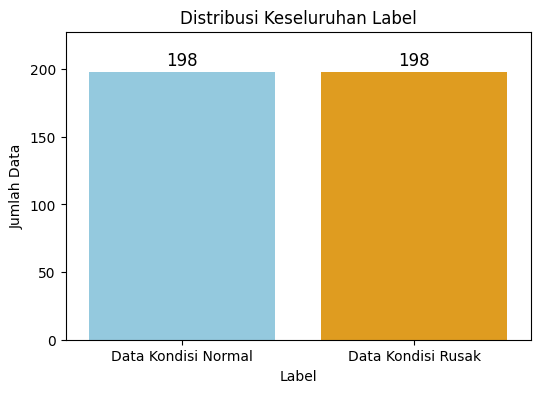

In [ ]:
plt.figure(figsize=(6,4))
label_counts = y.map({0: 'Data Kondisi Normal', 1: 'Data Kondisi Rusak'}).value_counts()

sns.barplot(
    x=label_counts.index,
    y=label_counts.values,
    palette={'Data Kondisi Normal': 'skyblue', 'Data Kondisi Rusak': 'orange'}
)

plt.title("Distribusi Keseluruhan Label")
plt.xlabel("Label")
plt.ylabel("Jumlah Data")

for i, val in enumerate(label_counts.values):
    plt.text(i, val + 5, str(val), ha='center', fontsize=12)

plt.ylim(0, max(label_counts.values) * 1.15)

plt.show()

## *4. Isolation Forest Implementation*

In [ ]:
X_normal = X_scaled[y == 0]
X_anomali = X_scaled[y == 1]

# AUGMENTASI DATA NORMAL (SEBELUM SPLIT)
np.random.seed(42)

noise_factor = 0.005 # mengatur BESAR noise (0.5%)
n_augment = 3 # total data = (1 + n_augment) × data asli

augmented_list = [X_normal]

for i in range(n_augment):
    noise = np.random.normal(
        loc=0,
        scale=noise_factor * X_normal.std(),
        size=X_normal.shape
    )
    X_normal_aug = X_normal + noise
    augmented_list.append(X_normal_aug)

# Gabungkan normal asli + seluruh hasil augmentasi
X_normal_final = pd.concat(
    augmented_list,
    ignore_index=True
)

print("Jumlah data normal:")
print(f"- Normal asli            : {len(X_normal)}")
print(f"- Jumlah augmentasi      : {n_augment}x")
print(f"- Total normal final     : {len(X_normal_final)}")

Jumlah data normal:
- Normal asli            : 198
- Jumlah augmentasi      : 3x
- Total normal final     : 792


In [ ]:
df_check = X_normal_final.copy()
df_check['is_duplicated'] = df_check.duplicated()

jumlah_duplikat = df_check['is_duplicated'].sum()

print("\n=== CEK DUPLIKASI DATA ===")
print(f"Total baris            : {len(df_check)}")
print(f"Jumlah duplikasi penuh : {jumlah_duplikat}")

if jumlah_duplikat == 0:
    print("✅ Tidak ada duplikasi baris identik")
else:
    print("⚠️ Ada data yang terduplikasi identik")



=== CEK DUPLIKASI DATA ===
Total baris            : 792
Jumlah duplikasi penuh : 0
✅ Tidak ada duplikasi baris identik


In [ ]:
stat_asli = X_normal.describe().loc[['mean', 'std']]
stat_aug  = X_normal_final.describe().loc[['mean', 'std']]

stat_compare = pd.concat(
    [stat_asli, stat_aug],
    keys=['Asli', 'Setelah_Augmentasi']
)

print("\n=== DISTRIBUSI STATISTIK DATA ===")
display(stat_compare)



=== DISTRIBUSI STATISTIK DATA ===


CalculateLoad       MAF  CoolantTemp  BatteryVoltage  \
Asli               mean      -0.086673  0.239551    -0.914323        0.939079   
                   std        0.325226  0.754460     0.569991        0.395455   
Setelah_Augmentasi mean      -0.086629  0.239547    -0.914421        0.939060   
                   std        0.324601  0.752855     0.568871        0.394564   

                         AccelSens.No.1Volt%  AccelSens.No.2Volt%  \
Asli               mean             0.299338             0.267185   
                   std              0.719004             0.741622   
Setelah_Augmentasi mean             0.299425             0.267015   
                   std              0.717662             0.740278   

                         AccelSensorOutNo.1  AccelSensorOutNo.2  \
Asli               mean            0.410587            0.287249   
                   std             0.613609            0.783584   
Setelah_Augmentasi mean            0.410594            0.287441   
                   std             0.612476            0.782229   

                         AccelFullyClose#1(AD)  AccelFullyCloseLearn#1  ...  \
Asli               mean               0.410587                0.894474  ...   
                   std                0.613609                0.633926  ...   
Setelah_Augmentasi mean               0.410547                0.894517  ...   
                   std                0.612347                0.632746  ...   

                         +BMVoltage  Injector(Port)  \
Asli               mean    0.936305       -0.077069   
                   std     0.424575        0.398274   
Setelah_Augmentasi mean    0.936360       -0.076989   
                   std     0.423766        0.397538   

                         InjectionVolum(Cylinder1)  EvapPurgeFlow  \
Asli               mean                  -0.201039      -0.661010   
                   std                    0.264533       0.124994   
Setelah_Augmentasi mean                  -0.201080      -0.660985   
                   std                    0.264072       0.124735   

                         TargetAir-FuelRatio   O2SB1S1  ShortFTB1S1  \
Asli               mean             0.081565  0.136896    -0.129342   
                   std              0.843129  0.962071     0.978975   
Setelah_Augmentasi mean             0.081573  0.136943    -0.129161   
                   std              0.841258  0.959931     0.976972   

                         LongFTB1S1  O2FTB1S1  IGNAdvance  
Asli               mean    0.722131 -0.129279    0.521940  
                   std     0.380213  0.977836    1.146730  
Setelah_Augmentasi mean    0.722103 -0.128978    0.522334  
                   std     0.379517  0.976019    1.144758  

[4 rows x 33 columns]

#### Isolation Forest Implementation - Pengujian Augmentasi Data Menggunakan Teknik Jittering

In [ ]:
# Pisahkan data normal & anomali berdasarkan label
X_normal = X_scaled[y == 0]
X_anomali = X_scaled[y == 1]


In [ ]:
# SPLIT DATA NORMAL (SETELAH AUGMENTASI)
X_train_normal, X_test_normal = train_test_split(
    X_normal_final,
    test_size=0.2,
    random_state=42
)

print("\nJumlah data normal setelah split:")
print(f"- Train normal : {len(X_train_normal)}")
print(f"- Test normal  : {len(X_test_normal)}")

X_test = pd.concat(
    [X_test_normal, X_anomali],
    ignore_index=True
)

y_test = pd.Series(
    [0]*len(X_test_normal) + [1]*len(X_anomali)
)

print("\nJumlah data test keseluruhan:")
print(f"- Test normal  : {len(X_test_normal)}")
print(f"- Test anomali : {len(X_anomali)}")
print(f"- Total test   : {len(X_test)}")

# Isolation Forest Model
model = IsolationForest(
    n_estimators=100,
    contamination="auto",
    random_state=42
)
model.fit(X_train_normal)

# Prediksi pada test set
y_pred = model.predict(X_test)  # -1 = Anomali, 1 = Normal
y_pred = [1 if val == -1 else 0 for val in y_pred]
anomaly_score = model.decision_function(X_test)

X_test_original = pd.DataFrame(
    scaler.inverse_transform(X_test),
    columns=X.columns
)

df_hasil = X_test_original.copy()
df_hasil['True_Label'] = y_test.replace({0: 'Normal', 1: 'Anomali'})
df_hasil['Prediksi'] = y_pred
df_hasil['Prediksi_Label'] = pd.Series(y_pred).replace({0: 'Normal', 1: 'Anomali'})
df_hasil['Anomaly_Score'] = anomaly_score



Jumlah data normal setelah split:
- Train normal : 633
- Test normal  : 159

Jumlah data test keseluruhan:
- Test normal  : 159
- Test anomali : 198
- Total test   : 357


Confusion Matrix (detail):
True Negative (TN) = 121  → Normal diprediksi Normal
False Positive (FP) = 38 → Normal diprediksi Anomali
False Negative (FN) = 1 → Anomali diprediksi Normal
True Positive (TP) = 197  → Anomali diprediksi Anomali

Evaluation Metrics:
Accuracy  : 0.8908
Precision : 0.8383
Recall    : 0.9949
F1-score  : 0.9099

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.76      0.86       159
     Anomali       0.84      0.99      0.91       198

    accuracy                           0.89       357
   macro avg       0.92      0.88      0.89       357
weighted avg       0.91      0.89      0.89       357



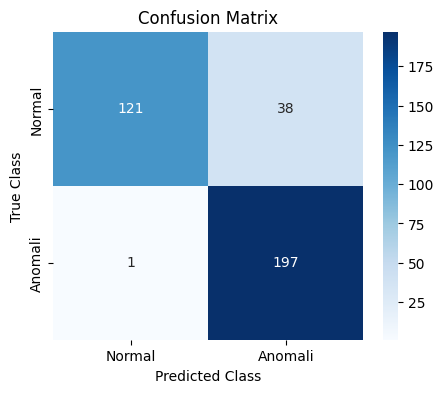

False Positive Rate (FPR): 0.2390
FPR (%): 23.90%


In [ ]:
# Evaluasi Model
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix (detail):")
print(f"True Negative (TN) = {tn}  → Normal diprediksi Normal")
print(f"False Positive (FP) = {fp} → Normal diprediksi Anomali")
print(f"False Negative (FN) = {fn} → Anomali diprediksi Normal")
print(f"True Positive (TP) = {tp}  → Anomali diprediksi Anomali\n")

# Hitung metrik evaluasi
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Evaluation Metrics:")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal','Anomali']))

# Plot Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Normal','Anomali'], yticklabels=['Normal','Anomali'])
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.show()

fpr = fp / (fp + tn)

print(f"False Positive Rate (FPR): {fpr:.4f}")
print(f"FPR (%): {fpr*100:.2f}%")

In [ ]:
# Data Anomali Terdeteksi
anomali_terdeteksi = df_hasil[df_hasil['Prediksi'] == 1]
normal_terdeteksi = df_hasil[df_hasil['Prediksi'] == 0]

# Informasi Jumlah Data
print("Ringkasan Hasil Deteksi:")
print("-------------------------------------")
print(f"Jumlah Data Anomali Terdeteksi : {len(anomali_terdeteksi)}")
print(f"Jumlah Data Normal Terdeteksi  : {len(normal_terdeteksi)}")
print("-------------------------------------")
print(f"Total Data                     : {len(df_hasil)}")

# --- Tampilkan Data Anomali ---
print("\nSeluruh Data Anomali Terdeteksi:")
display(anomali_terdeteksi)

Ringkasan Hasil Deteksi:
-------------------------------------
Jumlah Data Anomali Terdeteksi : 235
Jumlah Data Normal Terdeteksi  : 122
-------------------------------------
Total Data                     : 357

Seluruh Data Anomali Terdeteksi:


,CalculateLoad,MAF,CoolantTemp,BatteryVoltage,AccelSens.No.1Volt%,AccelSens.No.2Volt%,AccelSensorOutNo.1,AccelSensorOutNo.2,AccelFullyClose#1(AD),AccelFullyCloseLearn#1,...,TargetAir-FuelRatio,O2SB1S1,ShortFTB1S1,LongFTB1S1,O2FTB1S1,IGNAdvance,True_Label,Prediksi,Prediksi_Label,Anomaly_Score
12,21.497176,7.498587,74.999594,13.800195,21.500842,37.612176,0.999945,1.800070,0.998635,20.001074,...,1.000003,0.819906,1.502491,1.502502,1.575693,24.568031,Normal,1,Anomali,-0.020102
25,17.600000,5.530000,75.000000,13.800000,20.300000,36.000000,1.000000,1.700000,1.000000,20.000000,...,1.000000,0.070000,7.800000,1.500000,7.812000,23.500000,Normal,1,Anomali,-0.097390
26,22.302377,9.250247,75.017861,13.799616,22.279172,37.973146,1.100255,1.800149,1.101054,20.000285,...,1.000001,0.110036,6.203926,2.301929,6.241022,26.503098,Normal,1,Anomali,-0.034715
29,6.600802,3.963121,79.975570,13.800415,15.964285,31.682065,0.799845,1.500600,0.797954,20.499967,...,1.000000,0.848906,1.511296,2.304715,1.564306,22.004834,Normal,1,Anomali,-0.043423
37,31.300572,5.106828,75.003929,13.700112,20.001315,36.002970,0.899881,1.700888,0.900503,19.998848,...,1.000000,0.641809,-0.811605,1.496834,-0.797996,9.932907,Normal,1,Anomali,-0.081169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352,23.900000,4.250000,84.000000,13.600000,15.600000,31.700000,0.700000,1.500000,0.700000,19.500000,...,1.000000,0.010000,4.600000,0.700000,4.687000,10.500000,Anomali,1,Anomali,-0.073387
353,24.700000,4.030000,84.000000,13.500000,15.600000,31.700000,0.700000,1.500000,0.700000,19.500000,...,1.000000,0.010000,5.400000,0.700000,5.468000,10.500000,Anomali,1,Anomali,-0.057278
354,26.600000,4.100000,84.000000,13.500000,15.600000,31.700000,0.700000,1.500000,0.700000,19.500000,...,1.000000,0.010000,6.200000,0.700000,6.250000,10.500000,Anomali,1,Anomali,-0.100357
355,28.200000,4.060000,84.000000,13.500000,15.600000,31.700000,0.700000,1.500000,0.700000,19.500000,...,1.000000,0.010000,7.000000,0.700000,7.031000,10.500000,Anomali,1,Anomali,-0.113047


In [ ]:
display(normal_terdeteksi)

,CalculateLoad,MAF,CoolantTemp,BatteryVoltage,AccelSens.No.1Volt%,AccelSens.No.2Volt%,AccelSensorOutNo.1,AccelSensorOutNo.2,AccelFullyClose#1(AD),AccelFullyCloseLearn#1,...,TargetAir-FuelRatio,O2SB1S1,ShortFTB1S1,LongFTB1S1,O2FTB1S1,IGNAdvance,True_Label,Prediksi,Prediksi_Label,Anomaly_Score
0,19.981996,6.150426,78.009047,13.800042,20.304687,36.418976,0.999495,1.699804,1.001117,20.499769,...,1.000000,0.247480,0.711982,2.302163,0.789804,22.489572,Normal,0,Normal,0.008315
1,20.701192,11.959342,79.999675,13.800141,23.094555,39.204467,1.098968,1.899386,1.099538,20.499561,...,0.999999,0.678329,-6.303538,3.103870,-6.266865,34.096990,Normal,0,Normal,0.004857
2,19.602402,2.978830,74.993337,13.700029,16.012103,31.678043,0.802115,1.500025,0.800097,20.001473,...,0.999999,0.069043,2.307747,2.296179,2.345098,6.521798,Normal,0,Normal,0.080306
3,19.603749,2.946005,75.006258,13.700016,16.010365,31.707520,0.800515,1.498194,0.798939,20.001178,...,1.000001,0.739634,-0.000992,2.300666,0.003286,7.418082,Normal,0,Normal,0.093105
4,20.300000,10.400000,79.000000,13.800000,22.700000,38.400000,1.100000,1.900000,1.100000,20.500000,...,1.000000,0.760000,0.000000,3.100000,0.000000,31.000000,Normal,0,Normal,0.050678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,20.301997,10.250790,79.023238,13.800202,22.704778,38.394352,1.100124,1.901213,1.099969,20.498961,...,1.000001,0.801169,0.693753,3.100712,0.777894,30.992396,Normal,0,Normal,0.030859
153,19.622081,2.945860,75.009432,13.699419,16.014922,31.711725,0.800175,1.498457,0.799469,19.998632,...,1.000001,0.089865,3.096027,2.300397,3.139328,7.064547,Normal,0,Normal,0.065017
155,20.282388,12.741182,76.992925,13.799421,23.493985,39.216306,1.099736,1.901550,1.100293,20.000397,...,1.000000,0.478750,-2.390908,3.096338,-2.337005,35.039229,Normal,0,Normal,0.036914
156,17.991986,3.028426,79.993239,13.799756,16.027291,31.713998,0.800016,1.501205,0.798967,19.998440,...,0.999998,0.761878,-0.002543,2.302664,-0.006522,9.469993,Normal,0,Normal,0.072600


##### SHAP Value (Find Trouble Parameter)

In [ ]:
import shap

/tmp/ipython-input-2046187065.py:21: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


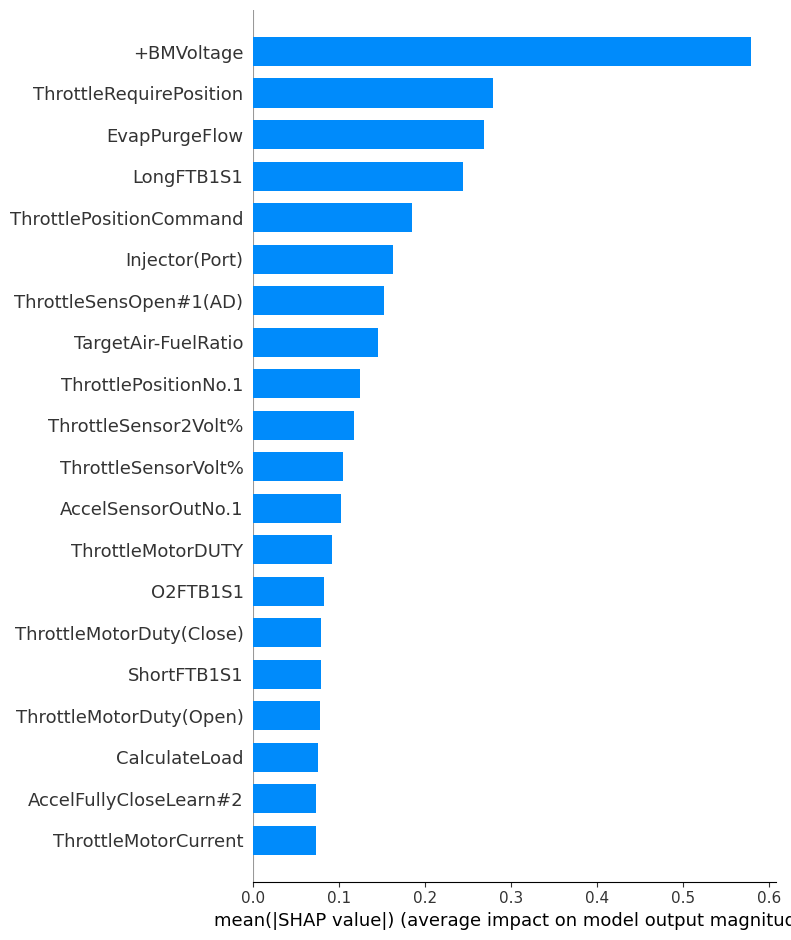

In [ ]:
X_test_shap = X_test.copy()
X_test_shap = X_test_shap.reset_index(drop=True)

df_hasil_shap = df_hasil.copy()
df_hasil_shap = df_hasil_shap.reset_index(drop=True)

explainer = shap.TreeExplainer(model)

shap_values_test = explainer.shap_values(X_test_shap)

# --- Ambil hanya data test yang diprediksi sebagai Anomali ---
anomali_idx = df_hasil_shap[df_hasil_shap['Prediksi_Label'] == 'Anomali'].index

X_anomali_for_shap = X_test_shap.loc[anomali_idx]
shap_values_anomali_for_shap = shap_values_test[anomali_idx]

# --- Visualisasi SHAP (bar plot) ---
shap.summary_plot(
    shap_values_anomali_for_shap,
    X_anomali_for_shap,
    plot_type="bar",
    show=True
)
